In [1]:
import os
from dotenv import load_dotenv
from typing import Literal, TypedDict, Sequence, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages    

In [2]:
import os
load_dotenv(override=True)

True

In [3]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        model_kwargs= {"temperature": 0.7},
        max_tokens= 1000,
        )
    
llm= get_groq_llm()
print(llm)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14', 'langchain-openai': '1.3.5'}} output_version=None client=<openai.resources.chat.completions.completions.Completions object at 0x0000012DAF6AF620> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000012DAF7EC1A0> root_client=<openai.OpenAI object at 0x0000012DA9769D30> root_async_client=<openai.AsyncOpenAI object at 0x0000012DAF6AFE00> model_name='openai/gpt-oss-120b' temperature=0.7 model_kwargs={} openai_api_key=SecretStr('**********') openai_api_base='https://api.groq.com/openai/v1' openai_proxy=None max_tokens=1000 stream_chunk_timeout=120.0


### Creating State

In [4]:

class ChatState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


### Agent

In [5]:
def agent(state: ChatState):
    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)
    
    # response store state
    return {'messages': [response]}



### Creating Workflow

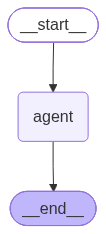

In [6]:
from langgraph.graph import START, END, StateGraph

graph = StateGraph(ChatState)
## Node
graph.add_node('agent', agent)

## Edge
graph.add_edge(START, 'agent')
graph.add_edge('agent', END)

chatbot = graph.compile()
chatbot



In [7]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='a58644c8-f339-4217-ab80-68d4b76ffc47'),
  AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 77, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 30, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.284218587, 'prompt_time': 0.002886929, 'completion_time': 0.105478964, 'total_time': 0.108365893}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'id': 'chatcmpl-ac739dbd-fe2e-4e65-a653-052463f1fdaf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f8a27-e421-73d3-bf12-5a3e2d2eeb30-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

### In Memory chatbot

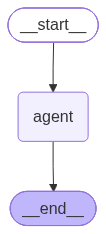

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, END, StateGraph

graph = StateGraph(ChatState)
## Node
graph.add_node('agent', agent)

## Edge
graph.add_edge(START, 'agent')
graph.add_edge('agent', END)

checkpointer= InMemorySaver()

chatbot=graph.compile(checkpointer= checkpointer)
chatbot


In [9]:
config= {'configurable':{'thread_id':'1'}}

initial_state = {
    'messages': [HumanMessage(content='Hi there my name is manirathinam')]
}

result=chatbot.invoke(initial_state, config= config)

result['messages'][-1].content

'Hello, Manirathinam! Nice to meet you. How can I assist you today?'

In [10]:
initial_state = {
    'messages': [HumanMessage(content='Do you remember my name?')]
}

result=chatbot.invoke(initial_state, config= config)

result['messages'][-1].content

'Yes, I remember—your name is Manirathinam. How can I help you today?'